In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Dataset ejemplo (puedes usar el tuyo)
data = pd.DataFrame({
    "Agua": [300, 280, 310, 290, 305, 315, 295],
    "Gasolina": [150, 160, 170, 180, 175, 165, 155],
    "Luz": [200, 210, 190, 205, 195, 215, 185],
    "Renta": [5000, 5000, 5000, 5000, 5000, 5000, 5000],
    "Super": [1200, 1300, 1100, 1250, 1280, 1180, 1220],
    "Total": [6850, 6980, 6770, 6925, 6950, 6875, 6855]
})

X = data.drop("Total", axis=1)
y = data["Total"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [2]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Crear y entrenar modelo
gbm = GradientBoostingRegressor(random_state=42, n_estimators=200, learning_rate=0.1, max_depth=3)
gbm.fit(X_train, y_train)

# Predicciones
y_pred = gbm.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📊 Evaluación Gradient Boosting:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


📊 Evaluación Gradient Boosting:
MAE : 36.73117076160603
RMSE: 40.95528062395399
R²  : 0.4712429037169391


In [3]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n📊 Comparación Random Forest:")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R²  :", r2_score(y_test, rf_pred))



📊 Comparación Random Forest:
MAE : 42.74166666666679
RMSE: 49.700144617496015
R²  : 0.2213331217162816


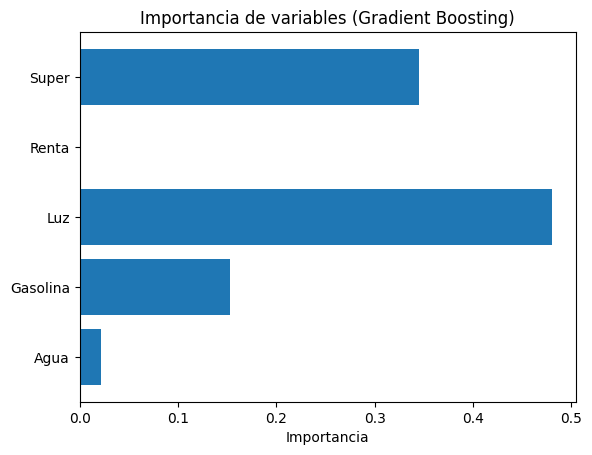

In [4]:
import matplotlib.pyplot as plt

features = X.columns
importances = gbm.feature_importances_

plt.barh(features, importances)
plt.xlabel("Importancia")
plt.title("Importancia de variables (Gradient Boosting)")
plt.show()
